# Demostration: Complex boundaries and diffraction points

In [ ]:
# track time of process
import time

# meshing
import gmsh

# math
import numpy as np

# graphics
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
# from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable

from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
import matplotlib.tri as tri


# set default font size in plots
plt.rcParams.update({'font.size': 20})
%matplotlib inline

# plotting violin plots 
import pandas as pd 
import seaborn as sns


## Importing local scripts and libraries into notebook


In [39]:
%reload_ext autoreload
%autoreload 2
import tritime2d as tt

## Create Mesh using GMSH

### Input parameters
**v1** : velocity in first layer 
**v2** : velocity in second layer 

**sx**,**sz** : position of source

**bx**,**bz** : width and depth of computational domain 

**layer_depth** : depth to layer 


**lcar** : mesh spacing at boundaries 

**scar** : mesh spacing at source

The source depth must be inside the computational area (i.e. 0 < sx < bx & 0 < sz < bz) as should the layer ( 0 < layer_depth < bz )

In [43]:
v1 = 1500
z0_1 = 0. 
vgrad_1 = 0. 

# boundary of meshing area 
bx = 1500.0 #1250.0 
bz = 1000.0

# location of diffraction point
diff_x = 1000.0 
diff_z = 800.0

sx = 800.0 #500.0 #diff_x 
sz = 0.0

lcar = 50.0/2
scar = 50.0/2
diff_car = 5 #scar 

In [44]:
print('slope close to source:', np.arctan2((diff_z-sz),(diff_x-sx))*180/np.pi)
print('slope at origin:',np.arctan2(diff_z,diff_x)*180/np.pi)

slope close to source: 75.96375653207353
slope at origin: 38.65980825409009


In [45]:
gmsh.initialize()
gmsh.model.add("Diffraction Test")


In [ ]:
nlayers = 1
v = [v1]
vgrad = [vgrad_1]
Grad_z0 = [z0_1]
gmsh.clear()

# source location 
# s1 = gmsh.model.geo.addPoint( sx, sz, 0, scar, 1) # add point source 
# add points
p1 = gmsh.model.geo.addPoint(0,  0, 0, lcar, 1)
p2 = gmsh.model.geo.addPoint(0,  bz, 0, lcar,2)
p3 = gmsh.model.geo.addPoint(bx, bz, 0, lcar,3)
p4 = gmsh.model.geo.addPoint(bx,  0, 0, lcar, 4)
s1 = gmsh.model.geo.addPoint( sx, sz, 0, scar, 5) # add point source 
# p6 = gmsh.model.geo.addPoint(diff_x,  diff_z, 0, lcar, 6)
p6 = gmsh.model.geo.addPoint(diff_x,  diff_z, 0, diff_car, 6)


# add lines
l_0 = gmsh.model.geo.addLine(p1, p2, 12)
l_1 = gmsh.model.geo.addLine(p2, p3, 23)
l_2 = gmsh.model.geo.addLine(p3, p4, 34)
l_3 = gmsh.model.geo.addLine(p4, s1, 45)
l_4 = gmsh.model.geo.addLine(s1, p6, 56)
l_5 = gmsh.model.geo.addLine(p6, p1, 61)

# curve loop
gmsh.model.geo.addCurveLoop([l_0, l_1, l_2, l_3, l_4, l_5], 1)

# make a surface
gmsh.model.geo.addPlaneSurface([1], 1)

# synchronize before adding point!
gmsh.model.geo.synchronize()

# give the surfaces physical values 
if nlayers > 1:
    for l in range(0, nlayers+1):
        gmsh.model.addPhysicalGroup(2,[l],l)  
else:
    gmsh.model.addPhysicalGroup(2,[1],1) 

gmsh.option.setNumber("Mesh.Algorithm", 5)  # Delaunay

mesh = gmsh.model.mesh.generate(2)   # put as 2 as we are generating a 2d mesh 

# write mesh to file 
# gmsh.write("test2.vtk") 

Info    : Clearing all models and views...
Info    : Done clearing all models and views
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 12 (Line)
Info    : [ 20%] Meshing curve 23 (Line)
Info    : [ 40%] Meshing curve 34 (Line)
Info    : [ 60%] Meshing curve 45 (Line)
Info    : [ 70%] Meshing curve 56 (Line)
Info    : [ 90%] Meshing curve 61 (Line)
Info    : Done meshing 1D (Wall 0.00445003s, CPU 0.004966s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Plane, Delaunay)
Info    : Done meshing 2D (Wall 0.0805431s, CPU 0.081049s)
Info    : 4960 nodes 9924 elements


### Extract the Nodes and Elements from the mesh


In [47]:
x, y, z, cells, cell_type = tt.extract_mesh()

In [48]:
cell_vel = tt.velocity_constant(len(cells), v1)

## Compute analytical solution 

In [49]:
nnodes = len(x)
diff_pt = [diff_x , diff_z]
theo_time = np.zeros(nnodes)
m1  = (diff_z-sz) / (diff_x-sx)
c1 = sz - m1*sx

m2  = diff_z / diff_x
c2 = 0. 


for i in range(nnodes):
    if (x[i] > sx) and (y[i] < m2*x[i]+c2) and (y[i] > m1*x[i]+c1):
        theo_time[i] = np.nan
    elif (x[i] < sx) and (y[i] < m2*x[i]+c2):
        theo_time[i] = np.nan
    elif (x[i] >= sx) and (y[i] <= m1*x[i]+c1):
        theo_time[i] = np.sqrt((x[i]-sx)**2+(y[i]-sz)**2)/v1
    else:
        primary_time = np.sqrt((sx-diff_x)**2+(sz-diff_z)**2)/v1
        sec_time = np.sqrt((x[i]-diff_x)**2+(y[i]-diff_z)**2)/v1
        theo_time[i] = primary_time+sec_time

### Assign initial travel time 

In [50]:
initial_time = tt.init_traveltime(sx, sz, x, y, cells, cell_vel)


Source location [800.0, 0.0], source is in cell 1842
Initial travel time on starting cell: [0.01666667 0.         0.01631048]
Source located at a single node


### Set diffraction points 

In [51]:
diff_zone = 2.5
diff_nodes = np.zeros(nnodes)
for i in range(nnodes):
    if (np.abs(y[i]- diff_z) < diff_zone) & (np.abs(x[i]- diff_x) < diff_zone):
        diff_nodes[i] = 1

### Plot Diffraction points and Initial Travel times

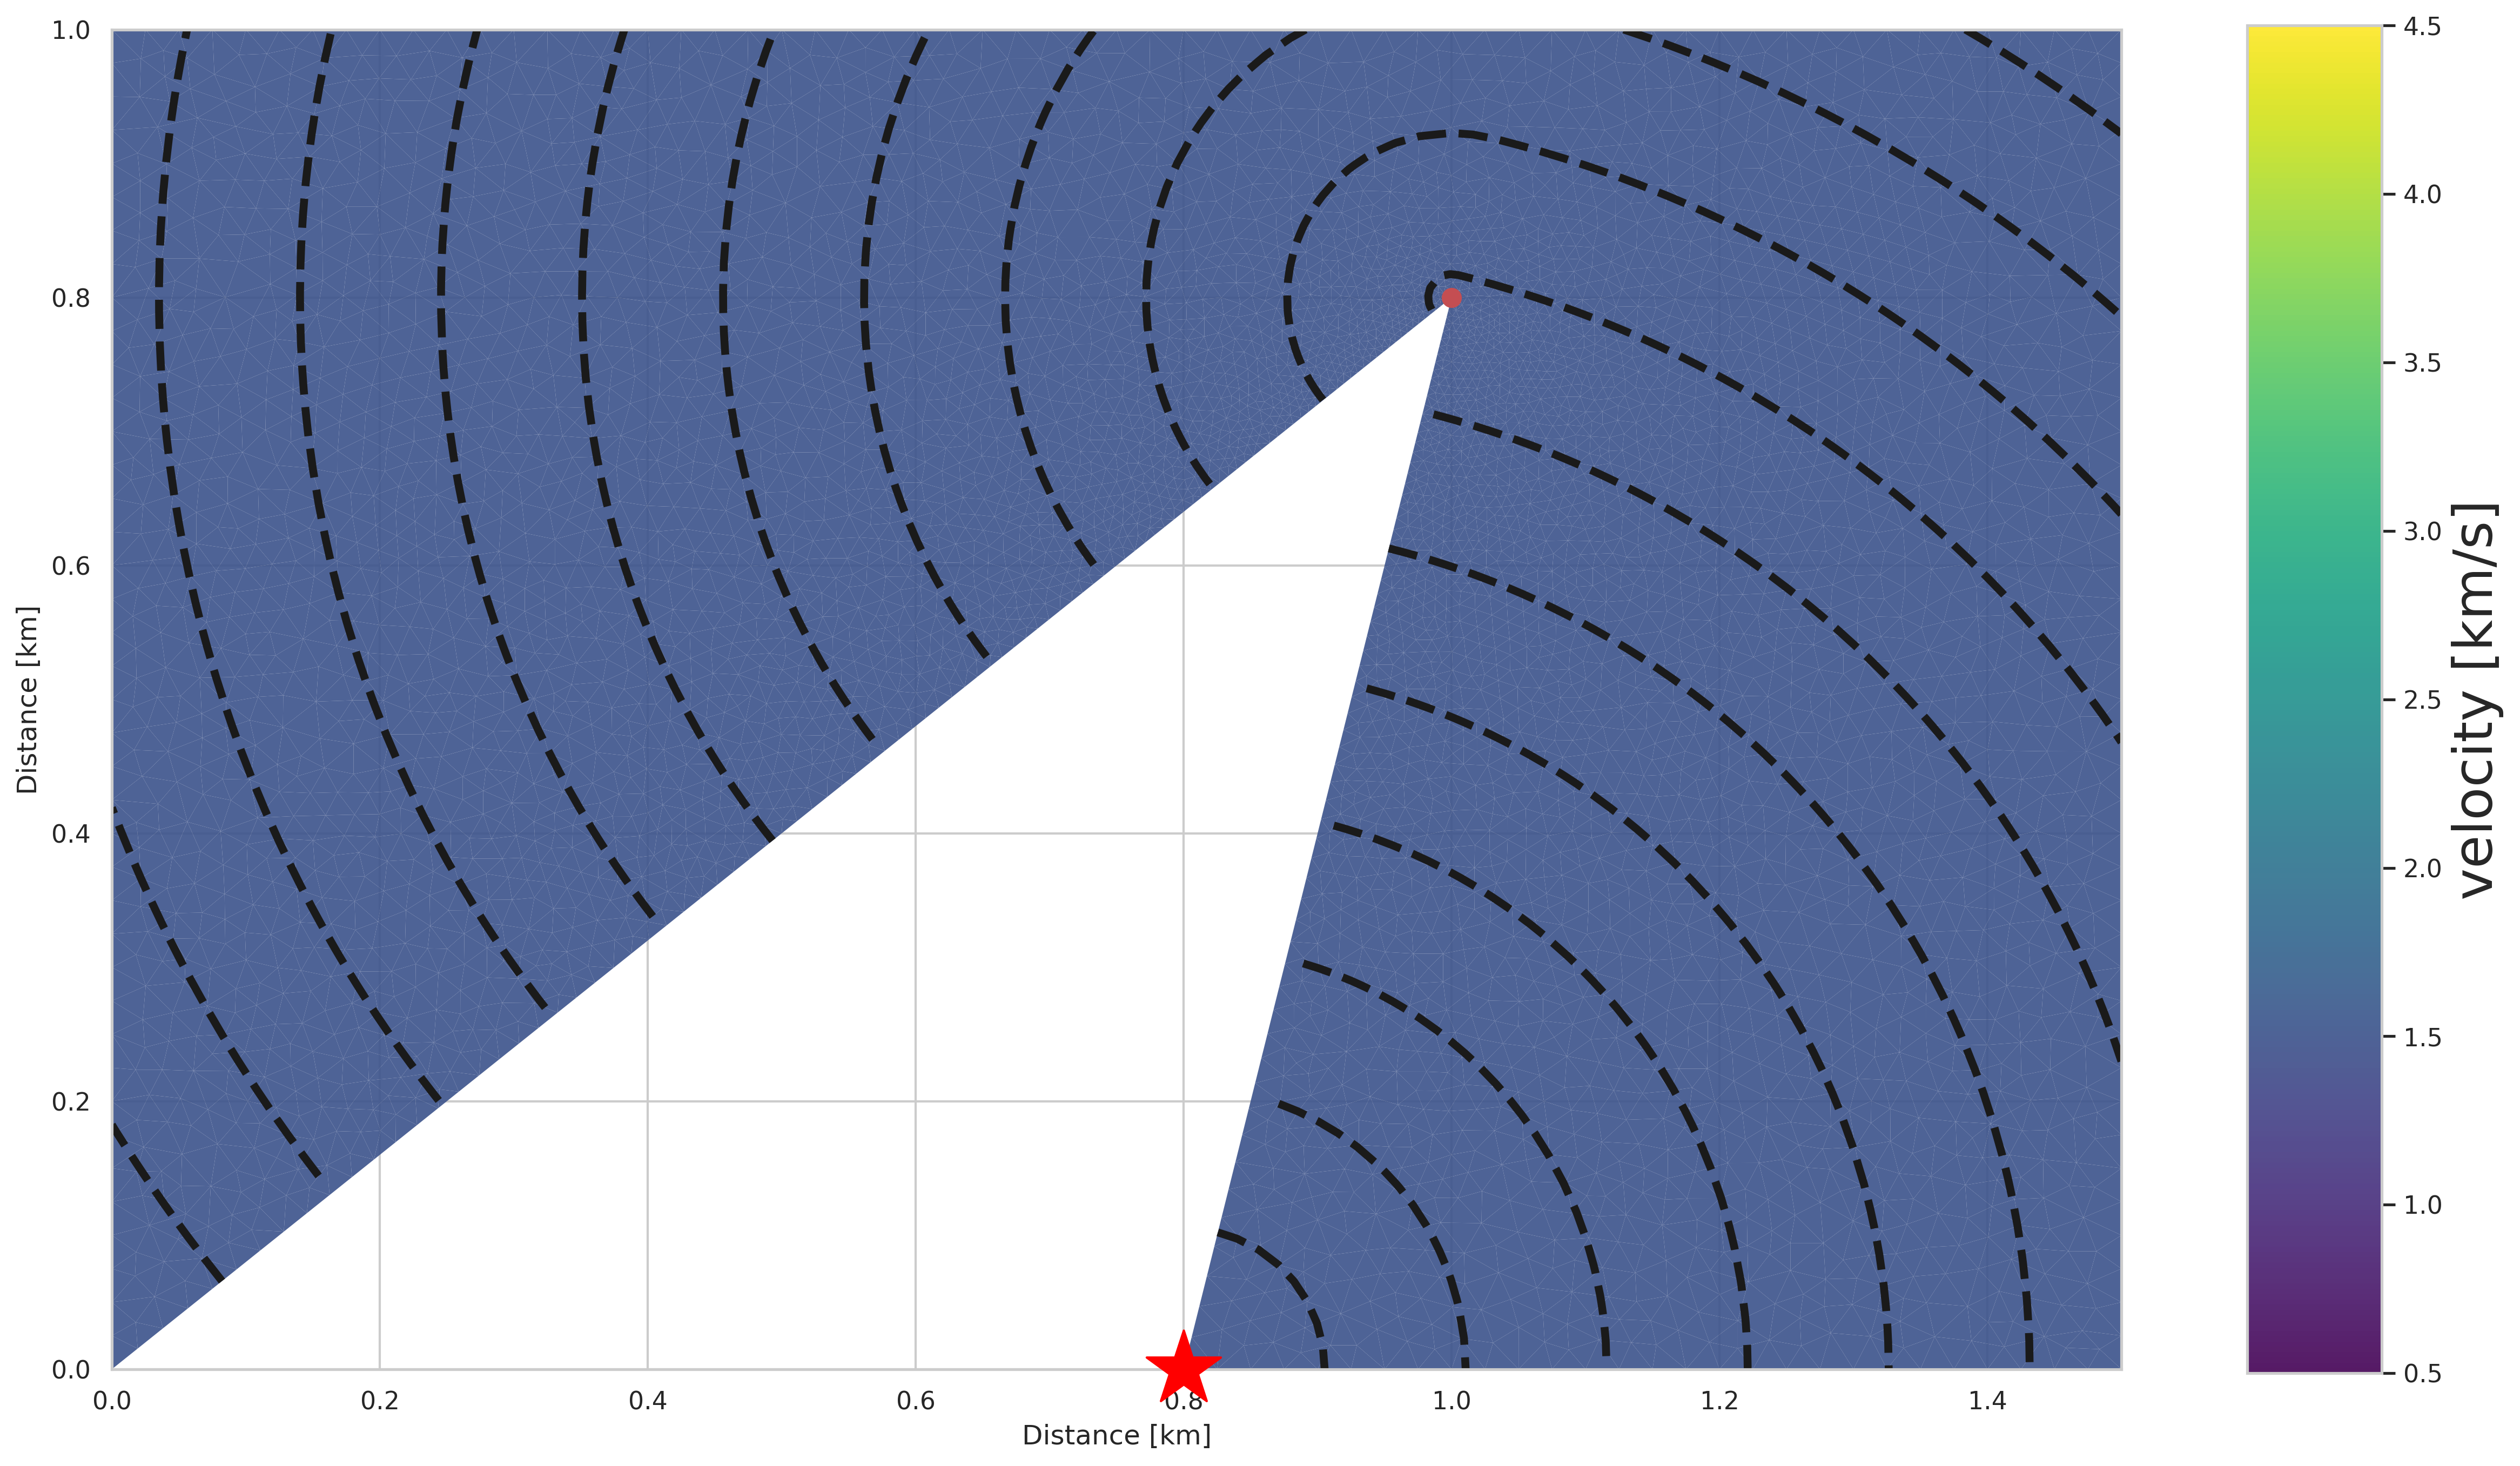

In [52]:
kilo = 1000

patches = []
for i in range(len(cells)):
    idx = cells[i]
    poly_pts = np.transpose(np.vstack((x[idx]/kilo,y[idx]/kilo)))
    polygon = Polygon(poly_pts)
    patches.append(polygon)


fig, ax = plt.subplots(figsize=(20,20), dpi=300)  
p = PatchCollection(patches, alpha=0.9,edgecolor='none', cmap='viridis')
p.set_array(cell_vel/kilo)
p.set_clim(vmin=0.5, vmax=4.5)  # Set your desired min/max values here

max_time = max(theo_time)
min_time = min(theo_time)
ncontours = 20
dc = (max_time-min_time)/ncontours
levels = np.arange(min_time, max_time+dc,dc )



# Build triangulation over all points
triang = tri.Triangulation(x/kilo, y/kilo,cells)

# Mask any triangle that has at least one nan vertex
nan_mask = np.any(np.isnan(theo_time[triang.triangles]), axis=1)
triang.set_mask(nan_mask)

# Replace nans with a safe dummy value (masked triangles won't use them)
theo_time_safe = np.where(np.isfinite(theo_time), theo_time, 0.)

tcf_tri = plt.tricontour(triang, theo_time_safe,
                         levels=levels, colors='k', linestyles='--', linewidths=3.5)



mask = diff_nodes > 0
if mask.any():
    plt.scatter(x[mask]/kilo, y[mask]/kilo, s=250, c='r', marker='.', zorder=5, label='Diffraction nodes')

ax.add_collection(p)
plt.scatter(sx/kilo, sz/kilo, c='red', s=1200, marker='*', label='Source',zorder=5, clip_on=False)

cbar = fig.colorbar(p, ax=ax,shrink=0.54, aspect=10, pad=0.05)
cbar.set_label('velocity [km/s]',fontsize=24)

plt.xlim(np.min(x/kilo),np.max(x/kilo)) 
plt.ylim(np.min(y/kilo),np.max(y/kilo)) # flip axis for depth
ax.set_aspect('equal')

ax.set_xlabel(r'Distance [km]')
ax.set_ylabel(r'Distance [km]')

plt.show()

In [53]:
print('In TriTime2d, no. of cells:', len(cell_vel), ' no. of nodes:', len(x))

In TriTime2d, no. of cells: 9579  no. of nodes: 4960


## Run TriTime2d

In [62]:
start=time.time()
traveltime = tt.tritime2d(x, y, z, cells, cell_vel, initial_time, diff_nodes, fast=False)
end=time.time()
print(end-start)

 starting trilateration.....
 first traveltime computation 
 diffraction points considered               6
 diffraction detected 
 next traveltime computation 
 diffraction points considered               0
0.02600407600402832


## Calculate error in traveltimes

In [55]:
mask = theo_time > 0.

safe_time = np.where(mask, theo_time, 1.)  # replace 0s with 1 to avoid divide-by-zero
Tri_Theo_diff = np.where(mask, (traveltime - theo_time) / safe_time * 100, 0.)

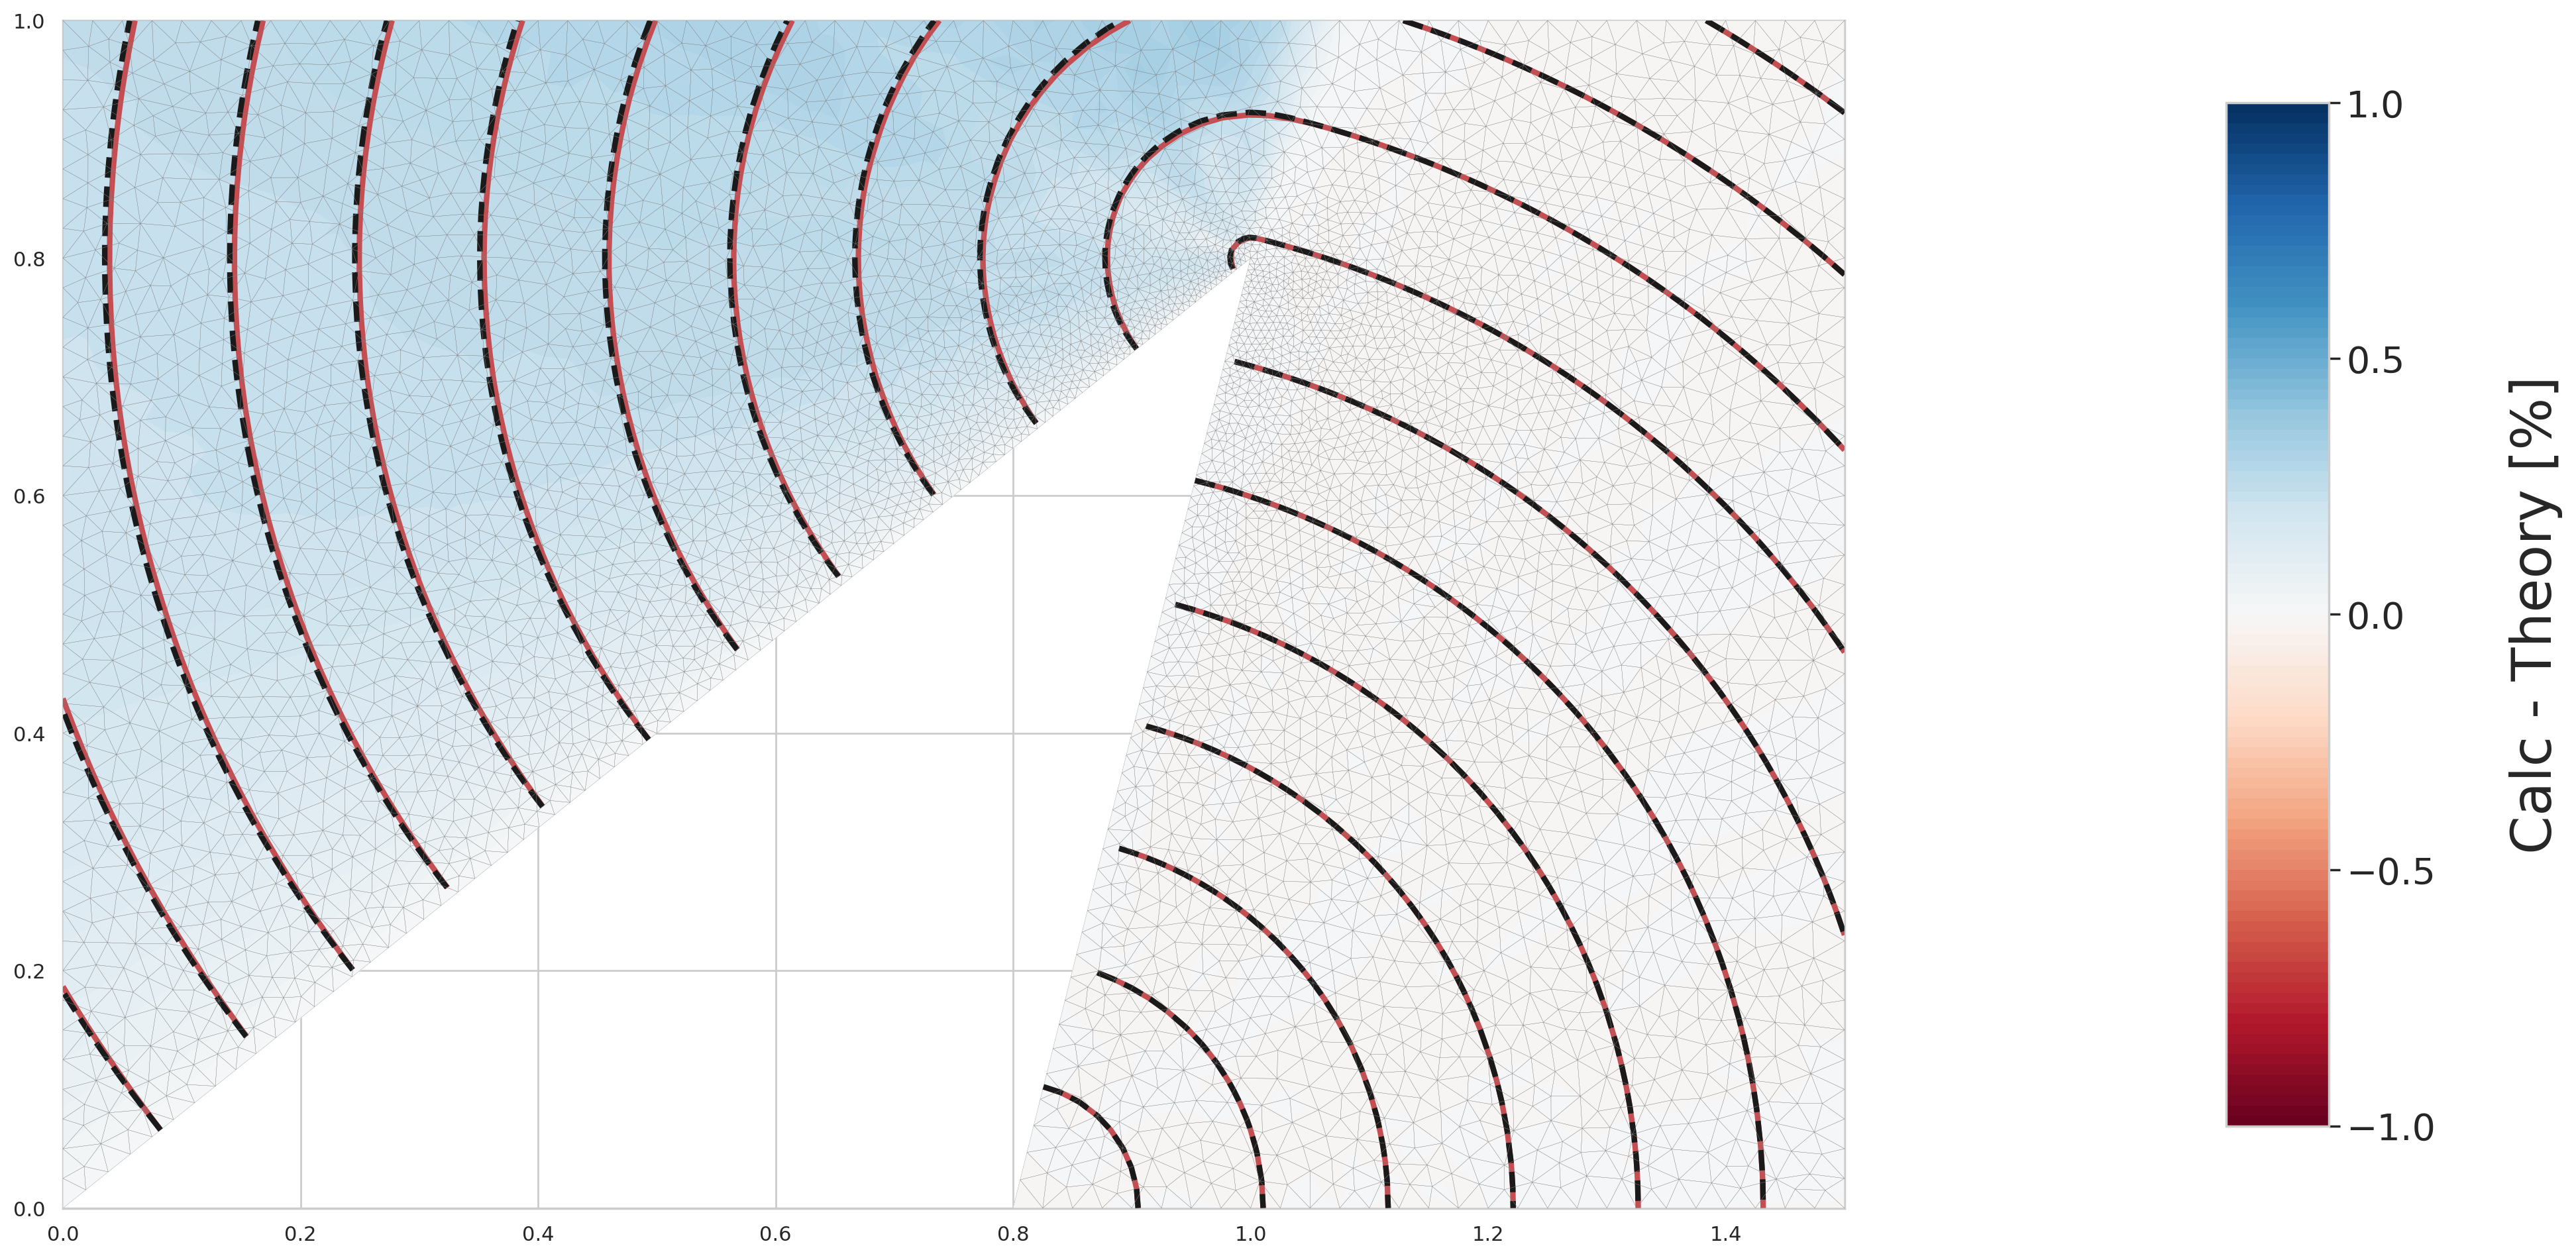

In [ ]:
# set colorbar range 
c_range = 1 # set colorbar range for image 

c_range = np.max(np.max((abs(np.max(Tri_Theo_diff)),abs(np.min(Tri_Theo_diff)))))
dcc = (2*c_range)/100
clevels=np.arange(-c_range,c_range+dcc,dcc )
# set contours 
ncontours = 20
dc = (max(traveltime)-min(traveltime))/ncontours
levels = np.arange(min(traveltime), max(traveltime)+dc,dc )

# Mask triangles where any vertex has NaN in the data
mask_tri_theo = np.any(np.isnan(theo_time[triang.triangles]), axis=1)
mask_tri_diff = np.any(np.isnan(Tri_Theo_diff[triang.triangles]), axis=1)
mask_tri_time = np.any(np.isnan(theo_time[triang.triangles]), axis=1)

# Apply masks
triang_theo = tri.Triangulation(x/kilo, y/kilo,cells)
triang_theo.set_mask(mask_tri_theo)

triang_diff = tri.Triangulation(x/kilo, y/kilo,cells)
triang_diff.set_mask(mask_tri_diff)

triang_tri = tri.Triangulation(x/kilo, y/kilo,cells)
triang_tri.set_mask(mask_tri_theo) # set mask based on theoretical time NaNs

fig2,ax1 = plt.subplots(figsize=(20, 20), dpi=200)

# mesh at the bottom — note /kilo to match the tricontourf coordinates
patches = [Polygon(np.column_stack((x[cells[i]]/kilo, y[cells[i]]/kilo)))
           for i in range(len(cells))]
mesh = PatchCollection(patches, facecolor='none', edgecolor='gray',
                       linewidth=0.1, zorder=5)
ax1.add_collection(mesh)

cc      = ax1.tricontourf(triang_diff, Tri_Theo_diff, clevels, cmap='RdBu', zorder=3)
tcf_tri = ax1.tricontour(triang_tri,  traveltime,     levels=levels, colors='r',
                         linewidths=3, linestyles='-',  zorder=4)
tcf_theo= ax1.tricontour(triang_theo, theo_time,       levels=levels, colors='k',
                         linewidths=3, linestyles='--', zorder=4)


ttrange = np.linspace(-c_range, c_range, 5, endpoint=True)
cb=plt.colorbar(cc,shrink=0.4, aspect=10, pad=0.15,ticks=ttrange)
cb.ax.tick_params(axis='both', which='major', labelsize=20)
cb.set_label('Calc - Theory [%]', fontsize=30, rotation=90, labelpad=40)

fig2.tight_layout()
ax1.set_aspect('equal')

plt.show()

Plot error distribution

In [57]:
print('error range:    ',np.max(Tri_Theo_diff),np.min(Tri_Theo_diff) ,'%')

error range:     0.3518935810574129 -1.4316943280978244e-13 %


In [58]:
# Create categories
categories = (['TriTime'] * len(Tri_Theo_diff))

# Combine the data
values = np.concatenate([Tri_Theo_diff])

# Create the DataFrame
df = pd.DataFrame({'Solver': categories, 'Error': values})

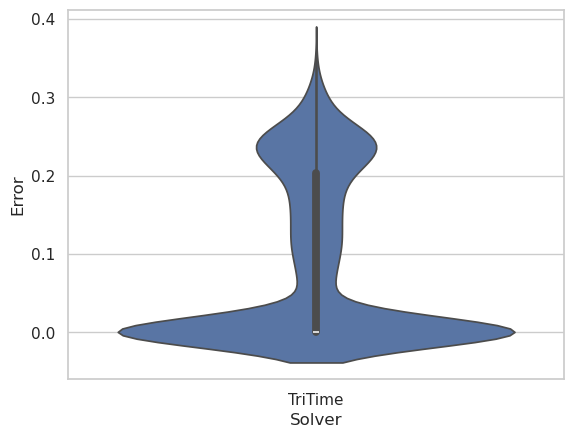

In [59]:
sns.set_theme(style="whitegrid")
ax = sns.violinplot(x="Solver", y="Error",data=df, hue="Solver",legend=False)
plt.show()

Write out results in a vtk file that can be read by paraview

In [ ]:
write_vtk(x, y, z, cells, cell_vel, traveltime, "Diffraction_Case.vtk")